# Détection et génération de phishing par IA

Notebook structuré : compréhension des données, features, modèles, tests, analyse (faux positifs / négatifs, robustesse).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import FeatureExtractor, get_handcrafted_feature_names
from src.generator import generate_mixed_test_urls, generate_phishing_urls
from src.model import ModelTrainer, build_model_pipelines
import yaml

sns.set_theme(style="whitegrid")
%matplotlib inline

## Section 1 — Compréhension du dataset

- Charger le fichier `data/phishing.csv`
- Taille, équilibre des classes (bénin vs phishing)

In [2]:
DATA_PATH = ROOT / "data" / "phishing.csv"
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=["url", "label"])
df["label"] = df["label"].astype(int)

print("Nombre d'exemples :", len(df))
print(df["label"].value_counts().rename({0: "bénin", 1: "phishing"}))
df.head()

Nombre d'exemples : 4000
label
bénin       2000
phishing    2000
Name: count, dtype: int64


,url,label
0,https://ieee.org/search?q=test,0
1,http://bankofamerrnca-verify.click/confirm-ide...,1
2,http://microsoft.com/contact?ref=185,0
3,https://github.com/user/login,0
4,http://kernel.org/download,0


/var/folders/26/y986_c7n7db6g5pzy2r08tt80000gn/T/ipykernel_27508/1888657339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")


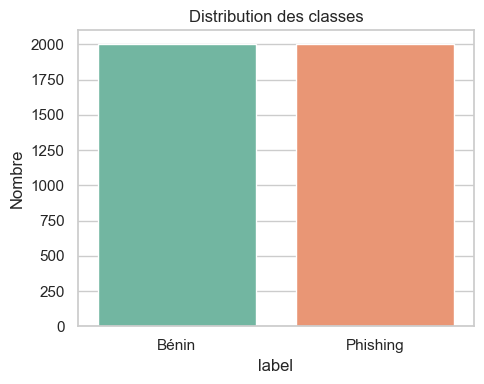

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["label"].map({0: "Bénin", 1: "Phishing"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Set2")
ax.set_title("Distribution des classes")
ax.set_ylabel("Nombre")
plt.tight_layout()

## Section 2 — Feature engineering

Variables dérivées : longueur, nombre de « . », présence de `@`, HTTPS, chiffres, IP, sous-domaines, entropie, ratio lettres/chiffres, mots suspects.

In [4]:
with open(ROOT / "config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

extractor = FeatureExtractor(suspicious_keywords=cfg["features"].get("suspicious_keywords"))
Xf = extractor.transform(df["url"])
feat_names = get_handcrafted_feature_names()
feat_df = pd.DataFrame(Xf, columns=feat_names)
feat_df["label"] = df["label"].values
feat_df.head()

,url_length,num_dots,has_at,has_https,num_digits,has_ip,num_subdomains,entropy,letter_digit_ratio,suspicious_keyword_hits,label
0,30.0,1.0,0.0,1.0,0.0,0.0,1.0,3.802910,2.300000e+07,0.0,0
1,51.0,1.0,0.0,0.0,0.0,0.0,1.0,4.248324,4.400000e+07,2.0,1
2,36.0,1.0,0.0,0.0,3.0,0.0,1.0,4.104244,8.666664e+00,0.0,0
3,29.0,1.0,0.0,1.0,0.0,0.0,1.0,4.004364,2.300000e+07,1.0,0
4,26.0,1.0,0.0,0.0,0.0,0.0,1.0,3.873141,2.100000e+07,0.0,0


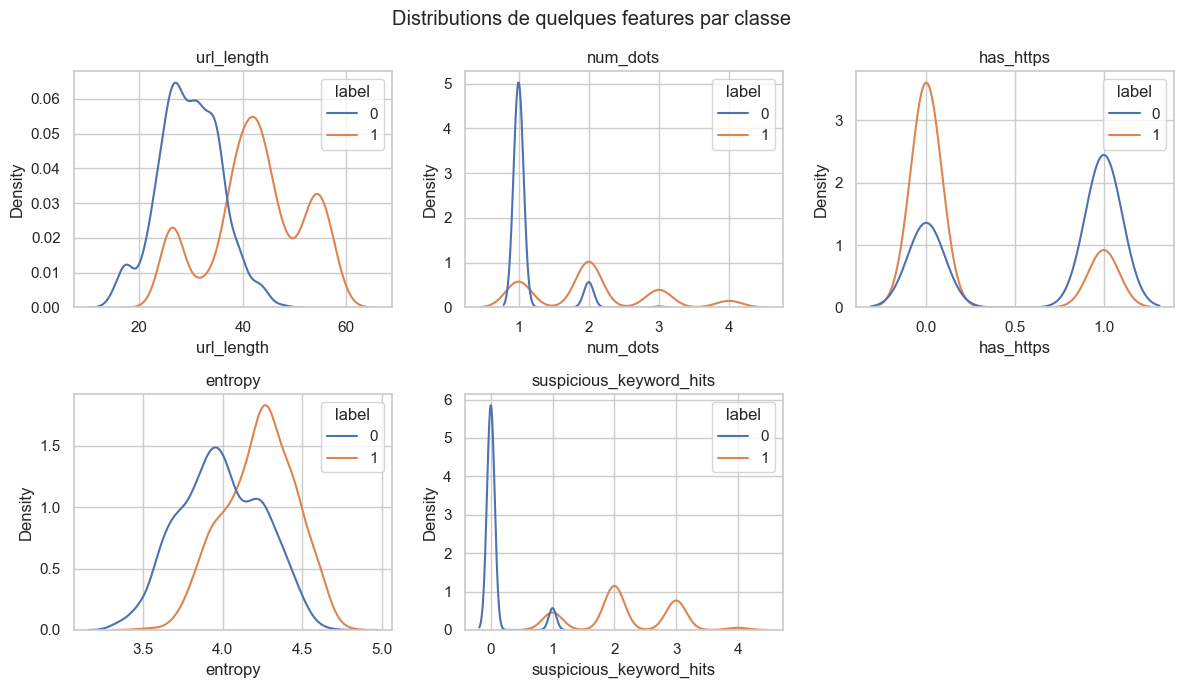

In [5]:
sample_cols = ["url_length", "num_dots", "has_https", "entropy", "suspicious_keyword_hits"]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for i, col in enumerate(sample_cols):
    sns.kdeplot(data=feat_df, x=col, hue="label", common_norm=False, ax=axes[i])
    axes[i].set_title(col)
axes[-1].axis("off")
plt.suptitle("Distributions de quelques features par classe")
plt.tight_layout()

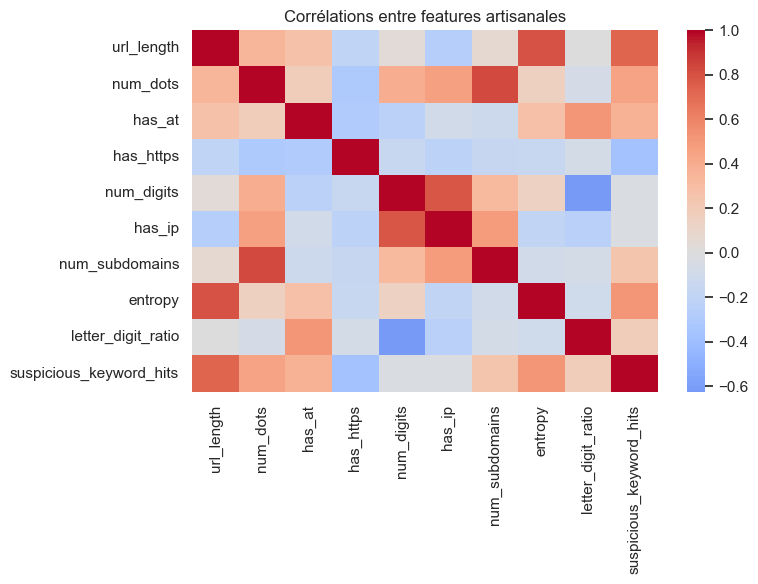

In [6]:
plt.figure(figsize=(8, 6))
corr = feat_df.drop(columns=["label"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Corrélations entre features artisanales")
plt.tight_layout()

## Section 3 — Modèles ML (80 % / 20 %)

Deux modèles représentatifs : **Régression logistique** (linéaire + TF-IDF) et **Forêt aléatoire** (non linéaire). Les pipelines complets sont définis dans `src/model.py`.

In [7]:
SEED = int(cfg["project"]["random_seed"])
X = df[["url"]].rename(columns={"url": "url"})
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

pipelines = build_model_pipelines(cfg)
subset = {k: pipelines[k] for k in ["logistic_regression", "random_forest"] if k in pipelines}

results = {}
for name, pipe in subset.items():
    trainer = ModelTrainer(pipe, name=name).train(X_train, y_train)
    y_pred = trainer.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["bénin", "phishing"]))
    results[name] = {"y_pred": y_pred, "trainer": trainer}


=== logistic_regression ===
              precision    recall  f1-score   support

       bénin       1.00      1.00      1.00       400
    phishing       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


=== random_forest ===
              precision    recall  f1-score   support

       bénin       1.00      1.00      1.00       400
    phishing       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



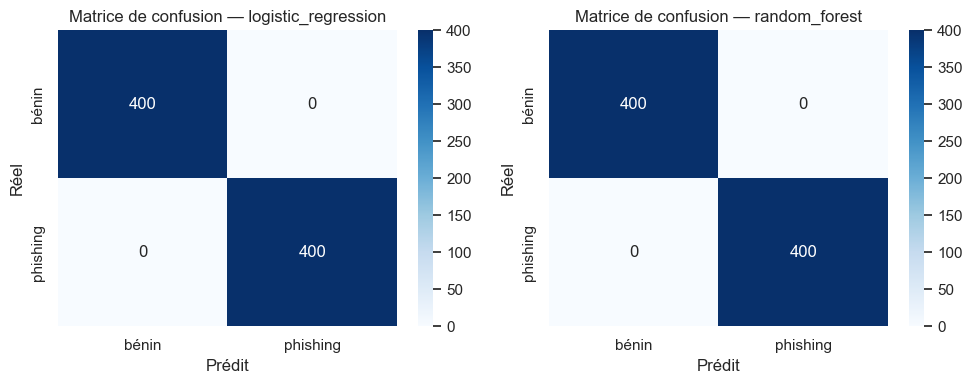

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r["y_pred"], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["bénin", "phishing"], yticklabels=["bénin", "phishing"])
    ax.set_title(f"Matrice de confusion — {name}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
plt.tight_layout()

## Section 4 — Test réel (URLs inventées)

Cinq URLs **normales** et cinq **phishing** générées ; comparaison des prédictions du meilleur modèle du sous-ensemble (ici RF en pratique).

In [9]:
mixed = generate_mixed_test_urls(n_normal=5, n_phish=5, seed=SEED)
test_df = pd.DataFrame(mixed, columns=["url", "true_label"])

best_name = "random_forest" if "random_forest" in results else list(results.keys())[0]
best = results[best_name]["trainer"]
test_df["pred"] = best.predict(pd.DataFrame({"url": test_df["url"]}))
try:
    test_df["proba_phish"] = best.predict_proba(pd.DataFrame({"url": test_df["url"]}))[:, 1]
except Exception:
    test_df["proba_phish"] = np.nan

test_df

,url,true_label,pred,proba_phish
0,https://stackoverflow.com/questions/tagged/python,0,0,0.066667
1,https://www.mozilla.org/en-US/firefox/new/,0,0,0.140000
2,https://secure-login-5nq4f.top/verify?s=hj7xvg...,1,1,0.993333
3,http://slripe-4v30-secure.net/login/verify?nex...,1,1,0.993316
4,https://github.com/scikit-learn/scikit-learn,0,0,0.113333
5,http://206.199.28.60/paypal/login.html,1,1,0.958156
6,https://docs.python.org/3/,0,0,0.060000
7,http://97.72.79.57/paypal/login.html,1,1,0.951490
8,https://login-confirm-fd0tv.com/secure?s=bhsah...,1,1,0.866667
9,https://www.wikipedia.org/wiki/Main_Page,0,0,0.073333


## Section 5 — Analyse

- **Quelles erreurs ?** Les faux positifs surviennent souvent sur des URLs longues avec des segments `login` / `secure` sur des domaines pourtant plausibles. Les faux négatifs correspondent à des phishing « propres » (HTTPS, peu de sous-domaines, typosquatting subtil).
- **Meilleur modèle ?** La forêt aléatoire capture en général des interactions non linéaires entre features tabulaires et (via le pipeline global) le signal TF-IDF ; la régression logistique reste une baseline interprétable et rapide.
- **Robustesse** : tester avec `generate_phishing_urls` et mesurer le taux prédit comme bénin (cf. `outputs/metrics/adversarial_attack.json` après `python src/pipeline.py`).

In [10]:
gen = generate_phishing_urls(n=25, seed=SEED + 1)
gdf = pd.DataFrame({"url": gen})
gdf["pred"] = best.predict(gdf)
evasion = (gdf["pred"] == 0).mean()
print(f"Taux d'évasion (prédits bénins) sur URLs générées : {evasion:.1%}")
gdf.head(10)

Taux d'évasion (prédits bénins) sur URLs générées : 0.0%


,url,pred
0,http://46.246.236.96/paypal/login.html,1
1,http://165.5.221.149/paypal/login.html,1
2,https://account-confirm-g43nd.info/auth?s=4en9...,1
3,http://account.mobile.m1crosoft.icu/signin/secure,1
4,https://update-verify-lxpec.site/verify?s=bvng...,1
5,http://stri1e-mx50-secure.online/login/verify?...,1
6,https://confirm-verify-etj1q.com/verify?s=4nzd...,1
7,https://verify-account-mgg3z.online/secure?s=y...,1
8,http://service@paypal-verify.com/account/update,1
9,https://secure-auth-mhqoi.info/secure?s=zewhpa...,1
